In [2]:
import pandas as pd
import numpy as np
#import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.tsa.stattools import ccf, grangercausalitytests
import matplotlib.cm as cm
import matplotlib.colors as mcolors
#import networkx as nx
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from matplotlib.colors import TwoSlopeNorm

In [3]:
def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['lat']))
    weighted_da = da * weights
    return weighted_da

def sea_mask(da):
    landsea_mask=xr.open_dataset('landseamask.nc') # mask values 0 (sea) or 1 (land)
    landsea_mask_interp = landsea_mask['mask'].interp(
    lat=da.lat,
    lon=da.lon,
    method='nearest') ##map my mask 0.5° on my 0.25° grid
    #print(landsea_mask.sel(lat=-32.25,lon=-50.25)['mask'].values)
    
    masked_da=da.where(landsea_mask_interp==1)
    return masked_da

In [4]:
def df_xr_prep(df):
    da=df.to_xarray()
    da=da.rename({'index':'year'})
    return da

##La Plata
#SON
era_SON_LaPlata_df=pd.read_csv('data_ready/7.csv',index_col='Unnamed: 0')

#era_SON_LaPlata_df=era_SON_LaPlata_df.rename(index_col='year')
era_SON_LaPlata_array=era_SON_LaPlata_df.to_xarray()
era_SON_LaPlata_array=era_SON_LaPlata_array.rename({'index':'year'})

#DJF
era_DJF_LaPlata_df=pd.read_csv('data_ready/6_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_LaPlata_array=df_xr_prep(era_DJF_LaPlata_df)

##Andes
#SON
era_SON_Andes_df=pd.read_csv('data_ready/5.csv',index_col='Unnamed: 0')
era_SON_Andes_array=df_xr_prep(era_SON_Andes_df)

#DJF
era_DJF_Andes_df=pd.read_csv('data_ready/4_with_IOBW_VB.csv', index_col='Unnamed: 0')
era_DJF_Andes_array=df_xr_prep(era_DJF_Andes_df)
display(era_DJF_Andes_array)

<xarray.Dataset> Size: 7kB
Dimensions:        (year: 72)
Coordinates:
  * year           (year) int64 576B 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t_Andes        (year) float64 576B -1.791 0.5614 -0.2617 ... 0.7645 0.6017
    precip_Andes   (year) float64 576B 0.129 0.4549 -1.375 ... -0.2223 -1.51
    ENSO           (year) float64 576B -0.6866 0.5838 0.3068 ... -0.7546 1.632
    IOD            (year) float64 576B 0.2555 0.6281 1.26 ... 0.9651 4.209
    EDJ            (year) float64 576B 1.783 0.6677 -0.5056 ... 0.9377 0.1875
    EDJ_lat        (year) float64 576B -0.6985 1.359 -0.9556 ... -2.241 -2.241
    EDJ_lat_nostd  (year) float64 576B -52.07 -48.64 -52.5 ... -54.64 -54.64
    SPV            (year) float64 576B 0.2633 -0.6312 1.451 ... 2.242 1.702 1.85
    A_SAM          (year) float64 576B 0.233 -1.135 -2.197 ... 1.774 0.05365
    S_SAM          (year) float64 576B 0.6038 -1.058 0.1437 ... 1.631 1.93 1.88
    IOBW           (year) float64 576B 0.984 -0.72 0.1245 ... 1.639 -2.263
    VB             (year) float64 576B 2.444 -0.4969 nan -0.4902 ... nan nan nan

In [5]:
def var_prepper(da, months_list, wghts_bool=True):
    ##1 Anomalies
    da_an=compute_anomaly(da)
    
    ##2 detrending
    p = da_an.polyfit(dim='time', deg=1, skipna=False)
    coeffs = p[list(p.data_vars)[0]]   # or p.t2m_polyfit_coefficients
    t_fit = xr.polyval(da_an['time'], coeffs)
    da_detr=da_an - t_fit
    
    ##3 weight by latitude (if necessary)
    if wghts_bool==True:
        da_wght=weight_by_latitude(da_detr)
    else:
        da_wght=da_detr
    ##4 extract seasonal data and standardise it again
    da_season=extract_seasonal_data(da_wght,months_list)
    if 12 in months_list:
        da_season_mean=stdize_ssavg(seasonal_average(shift_december(da_season)))
    else: 
        da_season_mean=stdize_ssavg(seasonal_average((da_season)))
        
    ##5 mask the ocean
    da_masked=sea_mask(da_season_mean)
    
    return da_masked

In [8]:
#load temperature era5 data
t_era=xr.open_dataset('data/era5_t2m.nc') #variable name is t2m
t_era=t_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
t_total=t_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

t_whole_SON=var_prepper(t_total, [9,10,11], wghts_bool=False)
t_whole_DJF=var_prepper(t_total, [12,1,2], wghts_bool=False)

In [9]:
##Era 5 precip data
pr_era=xr.open_dataset('data/era5_tp.nc')
pr_era=pr_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
pr_total=pr_era.sel(time=slice('1950','2024'),lat=slice(-20,-55),lon=slice(-76,-49)) 

pr_whole_SON=var_prepper(pr_total, [9,10,11], wghts_bool=False)
pr_whole_DJF=var_prepper(pr_total, [12,1,2], wghts_bool=False)

In [10]:
t_whole_SON.sel(lat=-32.25,lon=-50.25)

<xarray.Dataset> Size: 1kB
Dimensions:  (year: 75)
Coordinates:
    lat      float64 8B -32.25
    lon      float64 8B -50.25
  * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
Data variables:
    t2m      (year) float64 600B nan nan nan nan nan nan ... nan nan nan nan nan

In [11]:
print(np.unique(t_whole_SON.values))

[<bound method Mapping.values of <xarray.Dataset> Size: 9MB
 Dimensions:  (year: 75, lat: 141, lon: 105)
 Coordinates:
   * lat      (lat) float64 1kB -20.0 -20.25 -20.5 -20.75 ... -54.5 -54.75 -55.0
   * lon      (lon) float64 840B -76.0 -75.75 -75.5 -75.25 ... -50.5 -50.25 -50.0
   * year     (year) int64 600B 1950 1951 1952 1953 1954 ... 2021 2022 2023 2024
 Data variables:
     t2m      (year, lat, lon) float64 9MB nan nan nan nan ... nan nan nan nan>  ]


In [12]:
#display(t_LaPlata_ssavg_SON)

years_to_drop = [1950, 2002, 2019, 2025]

def exclude_years_xr(xr_obj, years):
    return xr_obj.sel(year=~xr_obj.year.isin(years))

##SON
t_whole_SON_ex=exclude_years_xr(t_whole_SON, years_to_drop)
pr_whole_SON_ex=exclude_years_xr(pr_whole_SON, years_to_drop)

##DJF
cut_years=[1950,2003,2020,2025]
t_whole_DJF_ex=exclude_years_xr(t_whole_DJF, cut_years)
pr_whole_DJF_ex=exclude_years_xr(pr_whole_DJF, cut_years)


In [13]:
##SON data
ds_SON = xr.merge([t_whole_SON_ex,pr_whole_SON_ex, era_SON_LaPlata_array])

##DJF data
ds_DJF=xr.merge([t_whole_DJF_ex,pr_whole_DJF_ex, era_DJF_LaPlata_array])

In [14]:
ds_SON.sel(lat=-30, lon=-50)

<xarray.Dataset> Size: 8kB
Dimensions:         (year: 72)
Coordinates:
    lat             float64 8B -30.0
    lon             float64 8B -50.0
  * year            (year) int64 576B 1951 1952 1953 1954 ... 2022 2023 2024
Data variables:
    t2m             (year) float64 576B -1.51 -1.382 -0.02297 ... 0.3631 1.057
    tp              (year) float64 576B 0.7865 -0.4533 1.368 ... 3.784 -1.324
    t_LaPlata       (year) float64 576B 1.008 -0.3405 0.001028 ... 1.707 1.963
    precip_LaPlata  (year) float64 576B 1.251 -1.636 2.576 ... 1.411 -0.9275
    ENSO            (year) float64 576B 0.8577 -0.08958 0.6573 ... 1.719 -0.33
    IOD             (year) float64 576B 0.1126 -0.4963 0.1753 ... 3.25 0.8168
    EDJ             (year) float64 576B -0.4128 -0.3213 ... -0.2175 -0.763
    EDJ_lat         (year) float64 576B 1.568 -1.369 0.8338 ... -0.1452 1.446
    EDJ_lat_nostd   (year) float64 576B -48.64 -53.79 -49.93 ... -51.64 -48.86
    SPV             (year) float64 576B -1.639 0.7289 -1.065 ... 0.9296 -0.05547
    A_SAM           (year) float64 576B -0.6832 0.7533 ... -0.6919 -0.4684
    S_SAM           (year) float64 576B -2.402 -0.386 -1.018 ... 0.5597 0.9627

In [41]:
def construct_da_x_year_fix(ds):
    ##this is a very confusing method, but I trust that it works...
    ds_roll=ds.rolling(year=30, center=False).construct("window")
    ds_roll_full=ds_roll.isel(year=slice(29, None))  # drop incomplete windows
    ds_chunked=ds_roll_full.chunk(lat=int(len(ds.lat)/4),lon=int(len(ds.lon)/4),year=-1)
    return ds_chunked

def lin_model_fast(y, x_main, *x_controls):
    """
    y         : (window,)
    x_main    : (window,)
    x_controls: (window,)

    Returns
    -------
    coef_main : float
    """

    # stack predictors
    X_list = [x_main] + list(x_controls)
    X = np.stack(X_list, axis=1)  # shape (window, n_predictors)

    # remove NaNs
    mask = ~np.any(np.isnan(X), axis=1) & ~np.isnan(y)
    if mask.sum() < X.shape[1]:  # not enough data
        return np.nan

    X = X[mask]
    y = y[mask]

    try:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
        return beta[0]  # coefficient of main predictor
    except np.linalg.LinAlgError:
        return np.nan
import xarray as xr

def sensitivity_analysis_fast(ds_rolled, target, driver, controls=None):
    """
    Perform regression for each grid point and rolling window.

    Parameters
    ----------
    ds_rolled : Dataset (year, window, lat, lon)
    target    : str (e.g. 't2m')
    driver    : str (main predictor, e.g. 'ENSO')
    controls  : list of str (optional)

    Returns
    -------
    coef_da : DataArray (year, lat, lon)
    """

    y = ds_rolled[target]
    x_main = ds_rolled[driver]

    if controls is not None:
        x_controls = [ds_rolled[var] for var in controls]
    else:
        x_controls = []

    coef = xr.apply_ufunc(
        lin_model_fast,
        y,
        x_main,
        *x_controls,
        input_core_dims=[["window"]] * (2 + len(x_controls)),
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    return coef


def conditioning_everything_fast(ds, driver_list, target, total_eff=False):
    """
    Compute regression maps for multiple drivers.

    Returns
    -------
    list of DataArrays (one per driver)
    """

    results = []

    # create rolling windows once
    ds_rolled = ds #construct_da_x_year_fix(ds)

    for driver in driver_list:

        # determine controls
        if not total_eff:
            controls = [d for d in driver_list if d != driver]

            if 'A_SAM' in driver_list and driver in ['SPV', 'VB', 'S_SAM']:
                if 'A_SAM' in controls:
                    controls.remove('A_SAM')

            elif ('SPV' in driver_list or 'VB' in driver_list) and driver == 'A_SAM':
                controls = [c for c in controls if c not in ['SPV', 'VB', 'S_SAM']]

        else:
            if driver == 'IOD' or driver=='IOBW':
                controls = ['ENSO']
            elif driver == 'SPV':
                controls = ['ENSO', 'IOD']
            elif driver == 'VB':
                controls = ['ENSO', 'IOBW']
            else:
                controls = None
        print(controls)
        coef = sensitivity_analysis_fast(
            ds_rolled,
            target=target,
            driver=driver,
            controls=controls
        )

        mean_coef = coef.mean(dim="year")

        results.append(mean_coef)

        print(f"{driver} done")

    return results

Whole Area Spring ERA5 data

In [25]:
temp_30_years=construct_da_x_year_fix(ds_SON)
temp_30_years

<xarray.Dataset> Size: 306MB
Dimensions:         (lat: 141, lon: 105, year: 43, window: 30)
Coordinates:
  * lat             (lat) float64 1kB -20.0 -20.25 -20.5 ... -54.5 -54.75 -55.0
  * lon             (lon) float64 840B -76.0 -75.75 -75.5 ... -50.5 -50.25 -50.0
  * year            (year) int64 344B 1980 1981 1982 1983 ... 2022 2023 2024
Dimensions without coordinates: window
Data variables:
    t2m             (year, lat, lon, window) float64 153MB dask.array<chunksize=(43, 35, 26, 30), meta=np.ndarray>
    tp              (year, lat, lon, window) float64 153MB dask.array<chunksize=(43, 35, 26, 30), meta=np.ndarray>
    t_LaPlata       (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>
    precip_LaPlata  (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>
    ENSO            (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>
    IOD             (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>
    EDJ             (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>
    EDJ_lat         (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>
    EDJ_lat_nostd   (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>
    SPV             (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>
    A_SAM           (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>
    S_SAM           (year, window) float64 10kB dask.array<chunksize=(43, 30), meta=np.ndarray>

In [42]:
##this is the short cut
result=conditioning_everything_fast(temp_30_years, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 't2m')


['IOD', 'SPV', 'A_SAM', 'S_SAM']
ENSO done
['ENSO', 'SPV', 'A_SAM', 'S_SAM']
IOD done
['ENSO', 'IOD', 'S_SAM']
SPV done
['ENSO', 'IOD']
A_SAM done
['ENSO', 'IOD', 'SPV']
S_SAM done


In [30]:
pr_reg_LP_SON=conditioning_everything_fast(temp_30_years, ['ENSO', 'IOD', 'SPV', 'A_SAM', 'S_SAM'], 'tp')

ENSO done
IOD done
SPV done
A_SAM done
S_SAM done


In [31]:
import cartopy.feature as cfeature

def plot_map(
    i,
    da,
    title,
    units,
    fig,
    subplts_num,
    cmap=plt.cm.viridis,
    cbar_each=None,
    levels=None,
    pval=None,
    fontsize=14,
    smooth=False,
):
    """
    Plot a regional map using only the spatial extent of da with PlateCarree.

    Parameters
    ----------
    da : xarray.DataArray
        DataArray with dimensions (lat, lon)
    pval : xarray.DataArray, optional
        p-values on same grid as da
    """
    # Extract coordinates
    lat = da.lat.values
    lon = da.lon.values
    arr = da.values

    # Create axis with PlateCarree projection
    ax = fig.add_subplot(1, subplts_num, i, projection=ccrs.PlateCarree())

    # Set extent to data region only
    ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

    # Colormap normalization
    # ---- FIX: always center at zero ----
    if cbar_each is None:
        vmax = np.nanmax(np.abs(arr))
    else:
        vmax=cbar_each
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    # Plot the field
    if smooth:
        cs = ax.contourf(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(), cmap=cmap)
    else:
        cs = ax.pcolormesh(lon, lat, arr, norm=norm, transform=ccrs.PlateCarree(),
                           cmap=cmap, shading="auto")

    ax.coastlines(resolution="50m")        # still keep coastlines
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)  # add country borders

    # Title
    ax.text(0.01, 1.02, title, transform=ax.transAxes, fontsize=fontsize)
    ax.set_adjustable('box')

    # Colorbar
    # ---- individual colorbars ----
    if cbar_each is None:
        cbar_ax = ax.inset_axes([0.05, -0.12, 0.9, 0.07])
        cbar = plt.colorbar(cs, orientation="horizontal", cax=cbar_ax,fraction=0.046,
                pad=0.08)
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(units, fontsize=fontsize)

    # Significance overlay
    if pval is not None:
        inds = np.argwhere(pval.values > 0.05)
        ax.plot(
            lon[inds[:, 1]],
            lat[inds[:, 0]],
            markersize=5.0,
            color="grey",
            marker=".",
            linestyle="None",
            transform=ccrs.PlateCarree(),
        )
    return cs

        
def subplots_map(ds, title_list, cmap=plt.cm.coolwarm, unit='K', cbar_each=None, heading=None):
    cs_list=[]
    fontsize=16
    global_max=0
    for da in ds:
        local_max = np.nanmax(np.abs(da.values))
        global_max = max(global_max, local_max)
        
    ##Find optimal figsize
    width_per_plot = 4
    height = 5 

    fig = plt.figure(figsize=(len(ds) * width_per_plot, height))
    fig.subplots_adjust(top=0.8)
    
    for j, da in enumerate(ds):
        
        cs=plot_map( #get the colorbar for each subplot
        i=j+1,
        da=da,
        pval=None,
        title=title_list[j],
        units=unit,
        cbar_each=global_max,
        fig=fig,
        subplts_num=len(ds),
        cmap=cmap,
        smooth=False,
        fontsize=fontsize)
        
        cs_list.append(cs)
    
    plt.tight_layout(rect=[0, 0.12, 1, 0.92])
    
    levels = np.linspace(-global_max, global_max, 7)  
    # → 10 color bins (adjust as you like)
    
    if not cbar_each:
        # create independent global norm
        global_norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

        sm = cm.ScalarMappable(norm=global_norm, cmap=cmap)
        sm.set_array([])
        
        cbar_ax = fig.add_axes([0.2, 0.08, 0.6, 0.03])
        cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
        cbar.ax.tick_params(labelsize=fontsize)
        cbar.set_label(unit, fontsize=fontsize)
        
    ##Heading
    if heading:
        fig.suptitle(heading, y=1.1, fontweight='bold', fontsize=18)
        fig.savefig('maps/'+heading+'.jpg', dpi=300, bbox_inches='tight')
    
    plt.show()

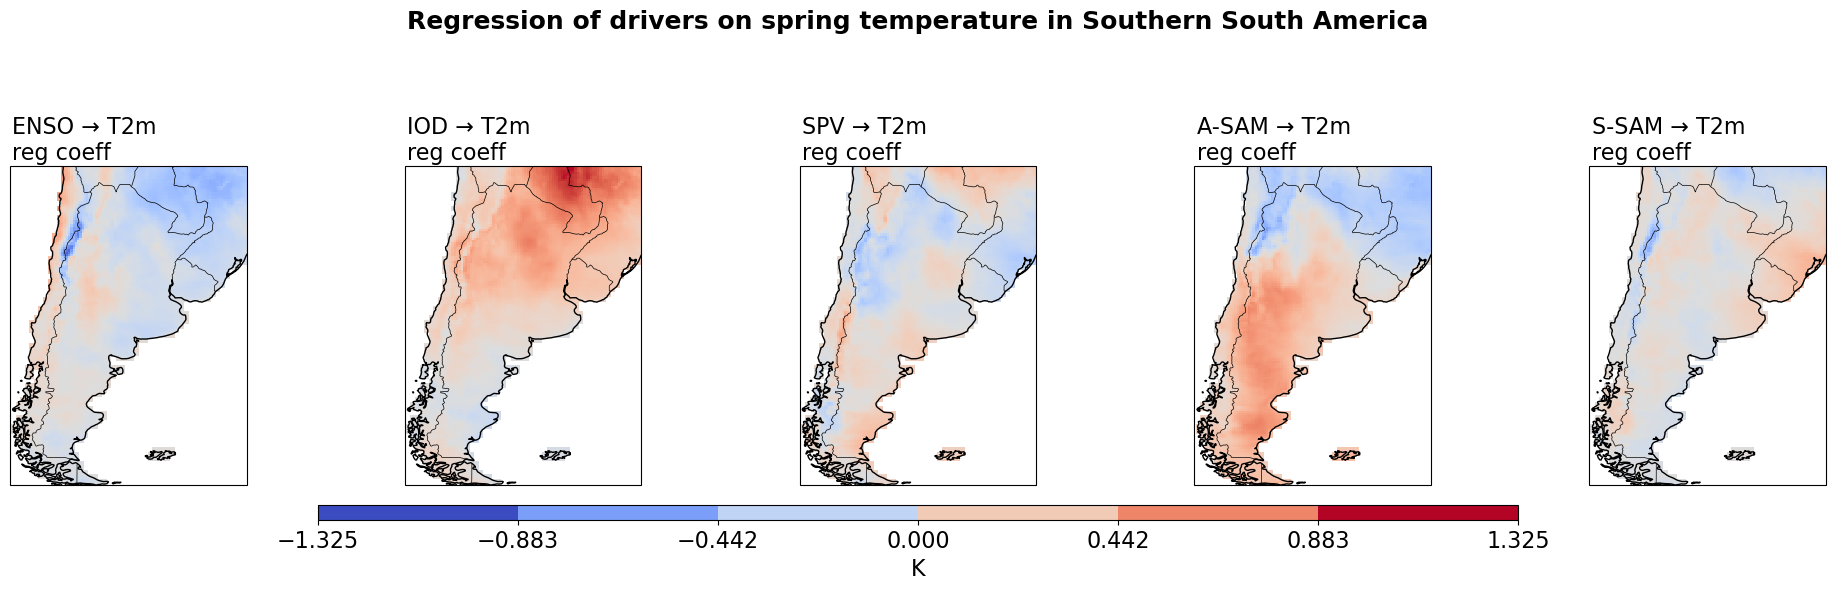

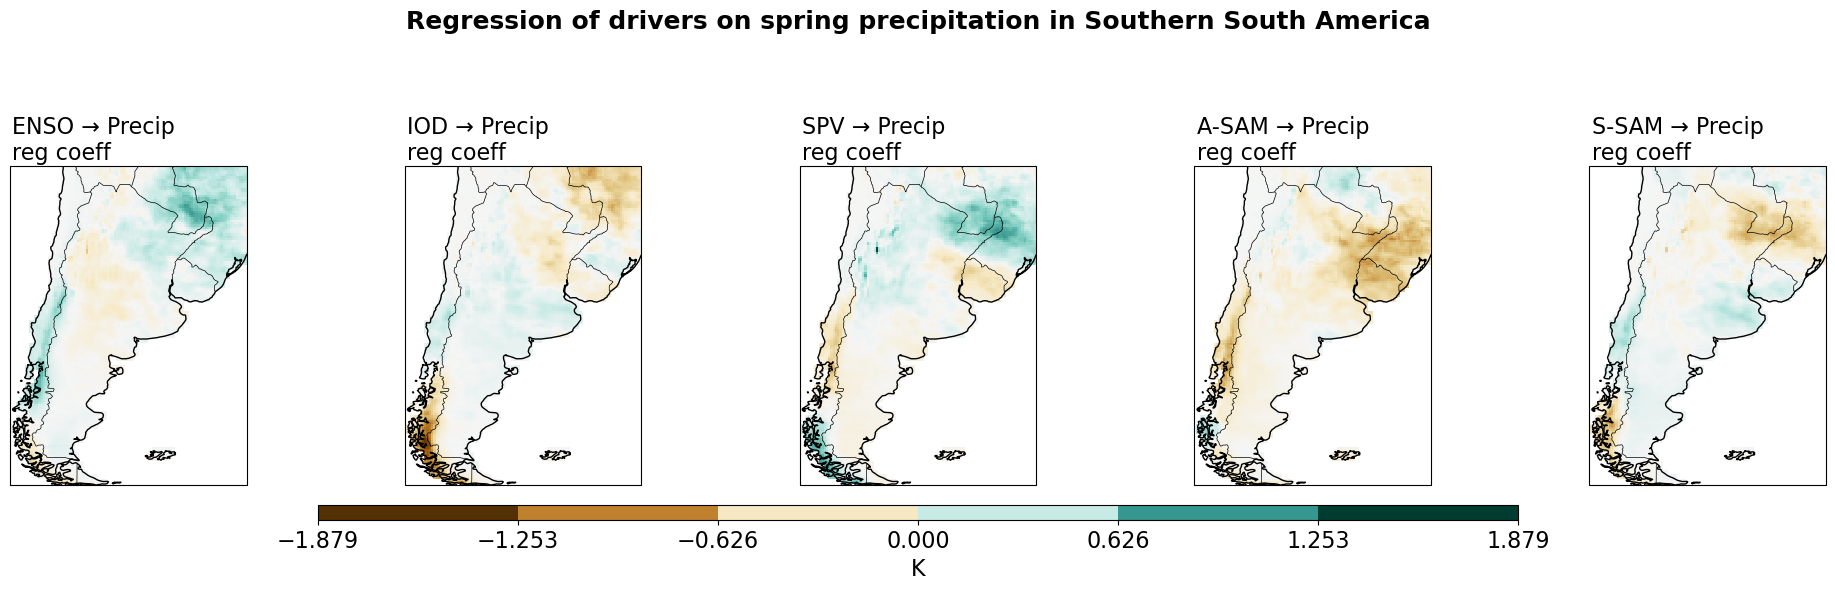

In [33]:
#print(result)
subplots_map(result, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], heading='Regression of drivers on spring temperature in Southern South America')

subplots_map(pr_reg_LP_SON, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading='Regression of drivers on spring precipitation in Southern South America')

In [43]:
##total effect of temp and precip in LP
t_reg_LP_SON_tot=conditioning_everything_fast(temp_30_years, ['ENSO', 'IOD', 'SPV'], 't2m',total_eff=True)
pr_reg_LP_SON_tot=conditioning_everything_fast(temp_30_years, ['ENSO', 'IOD', 'SPV'], 'tp',total_eff=True)

None
ENSO done
['ENSO']
IOD done
['ENSO', 'IOD']
SPV done
None
ENSO done
['ENSO']
IOD done
['ENSO', 'IOD']
SPV done


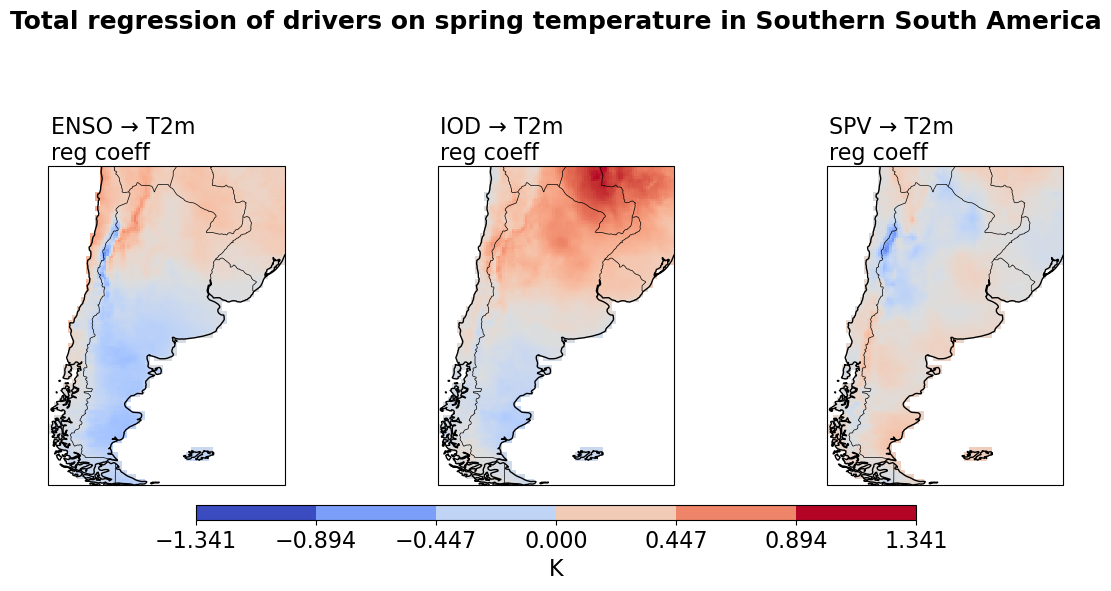

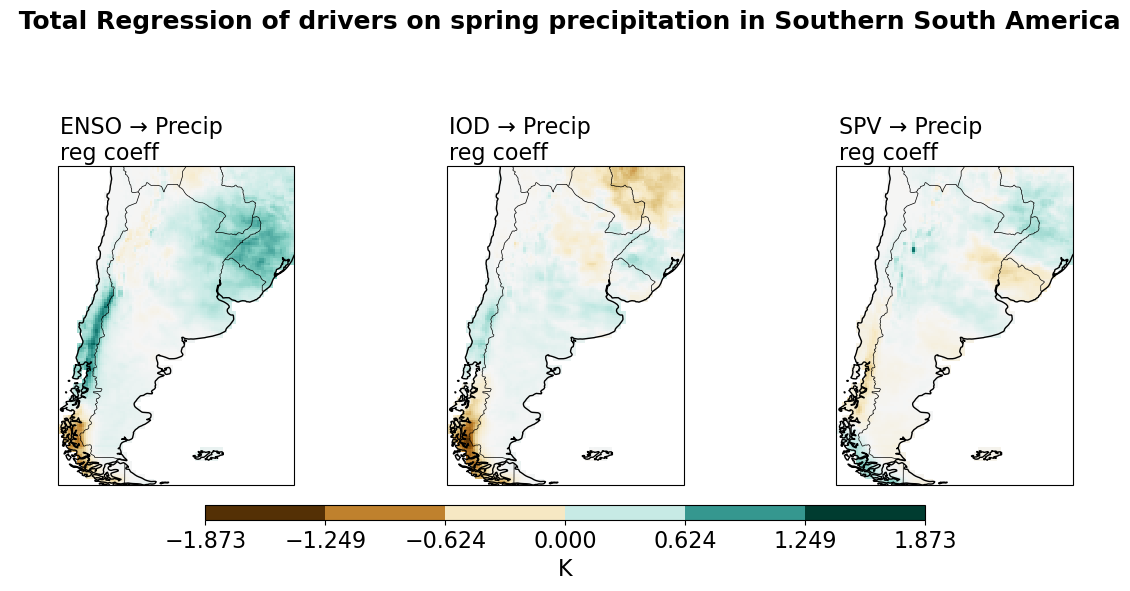

In [35]:
subplots_map(t_reg_LP_SON_tot, [f"ENSO → T2m \nreg coeff", f"IOD → T2m \nreg coeff", f"SPV → T2m \nreg coeff", \
                      ], heading='Total regression of drivers on spring temperature in Southern South America')
subplots_map(pr_reg_LP_SON_tot, [f"ENSO → Precip \nreg coeff", f"IOD → Precip \nreg coeff", f"SPV → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading=' Total Regression of drivers on spring precipitation in Southern South America')

Whole Area Summer ERA5 data

In [44]:
temp_30_years_LP_DJF=construct_da_x_year_fix(ds_DJF)
LP_summer_t_reg=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOBW', 'VB', 'A_SAM', 'S_SAM'], 't2m')
LP_summer_pr_reg=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOBW', 'VB', 'A_SAM', 'S_SAM'], 'tp')

['IOBW', 'VB', 'A_SAM', 'S_SAM']
ENSO done
['ENSO', 'VB', 'A_SAM', 'S_SAM']
IOBW done
['ENSO', 'IOBW', 'S_SAM']
VB done
['ENSO', 'IOBW']
A_SAM done
['ENSO', 'IOBW', 'VB']
S_SAM done
['IOBW', 'VB', 'A_SAM', 'S_SAM']
ENSO done
['ENSO', 'VB', 'A_SAM', 'S_SAM']
IOBW done
['ENSO', 'IOBW', 'S_SAM']
VB done
['ENSO', 'IOBW']
A_SAM done
['ENSO', 'IOBW', 'VB']
S_SAM done


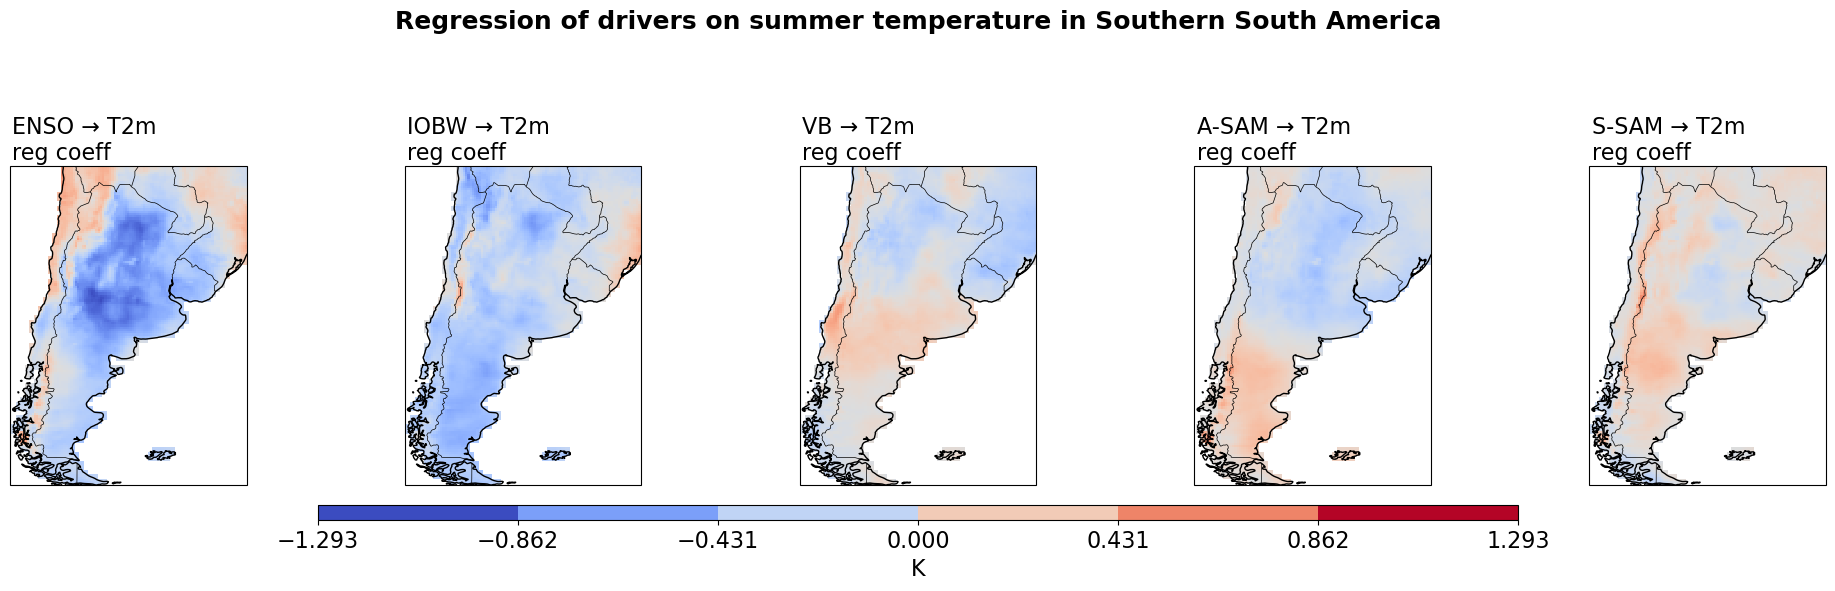

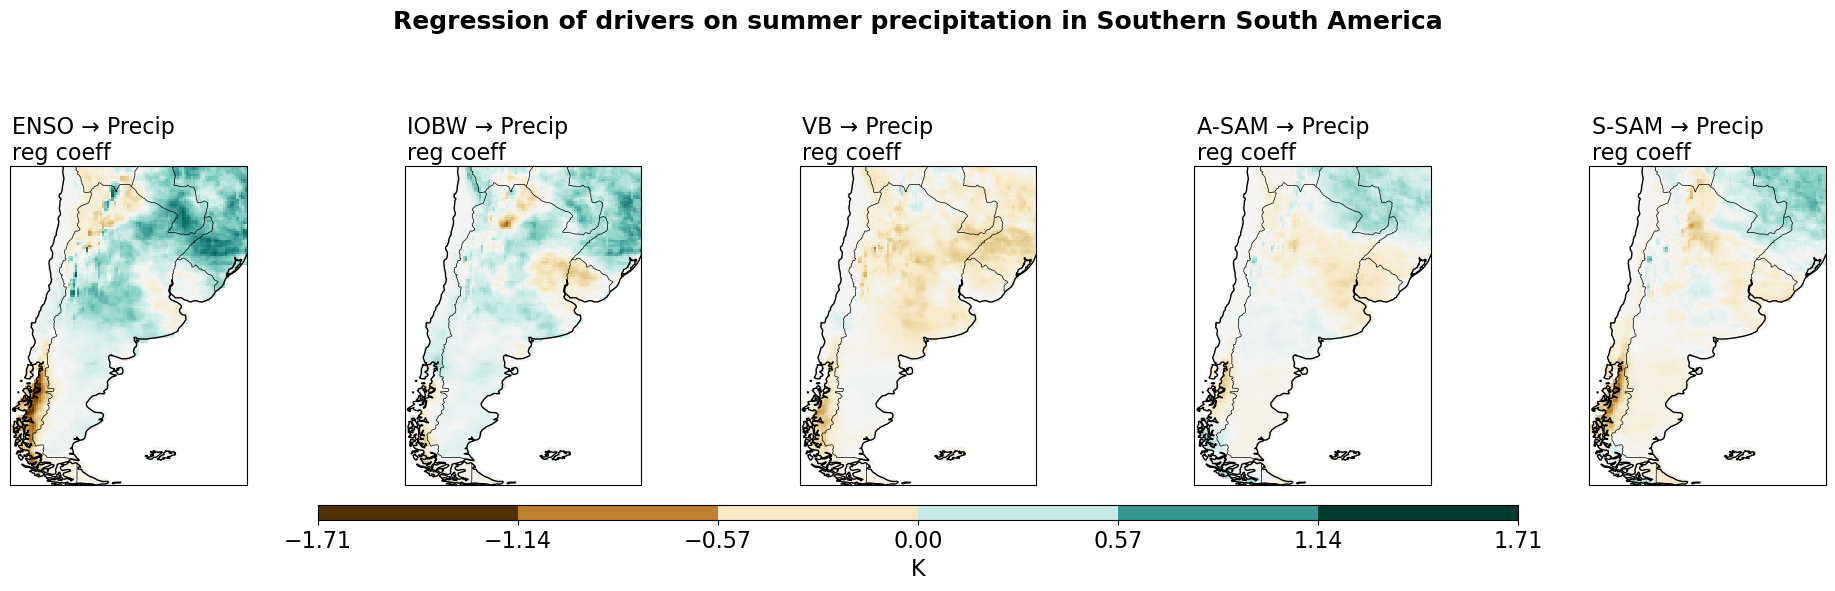

In [38]:
#print(result)
subplots_map(LP_summer_t_reg, [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff", f"VB → T2m \nreg coeff", \
                      f"A-SAM → T2m \nreg coeff", f"S-SAM → T2m \nreg coeff"], \
             heading='Regression of drivers on summer temperature in Southern South America')

subplots_map(LP_summer_pr_reg, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff", f"VB → Precip \nreg coeff", \
                      f"A-SAM → Precip \nreg coeff", f"S-SAM → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading='Regression of drivers on summer precipitation in Southern South America')

In [45]:
##total effect of temp and precip in LP
t_reg_LP_DJF_tot=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOBW', 'VB'], 't2m',total_eff=True)
pr_reg_LP_DJF_tot=conditioning_everything_fast(temp_30_years_LP_DJF, ['ENSO', 'IOBW', 'VB'], 'tp',total_eff=True)

None
ENSO done
['ENSO']
IOBW done
['ENSO', 'IOBW']
VB done
None
ENSO done
['ENSO']
IOBW done
['ENSO', 'IOBW']
VB done


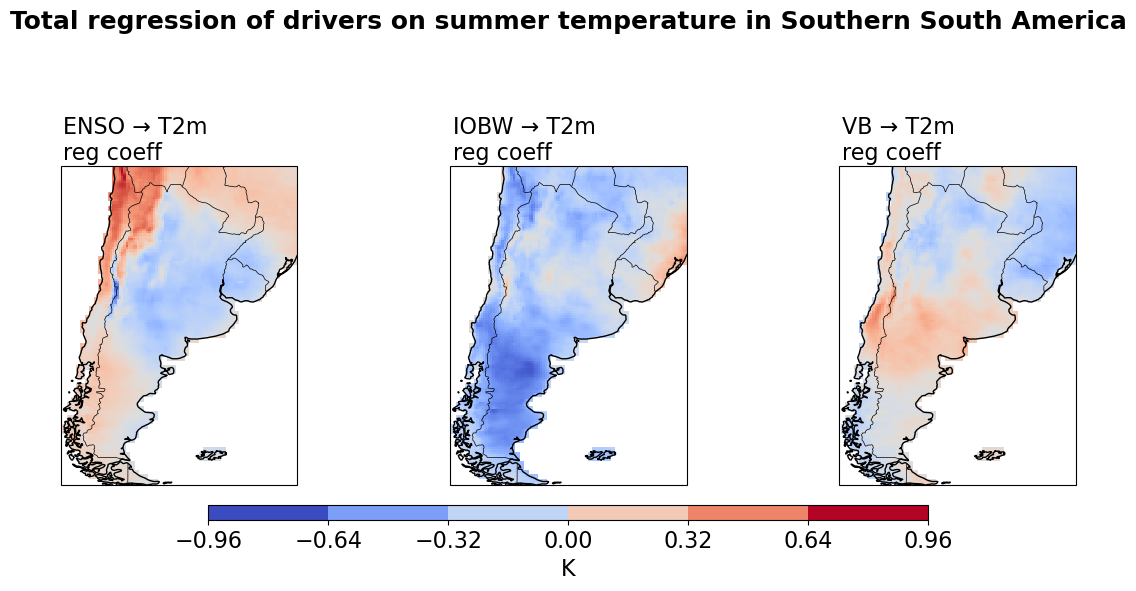

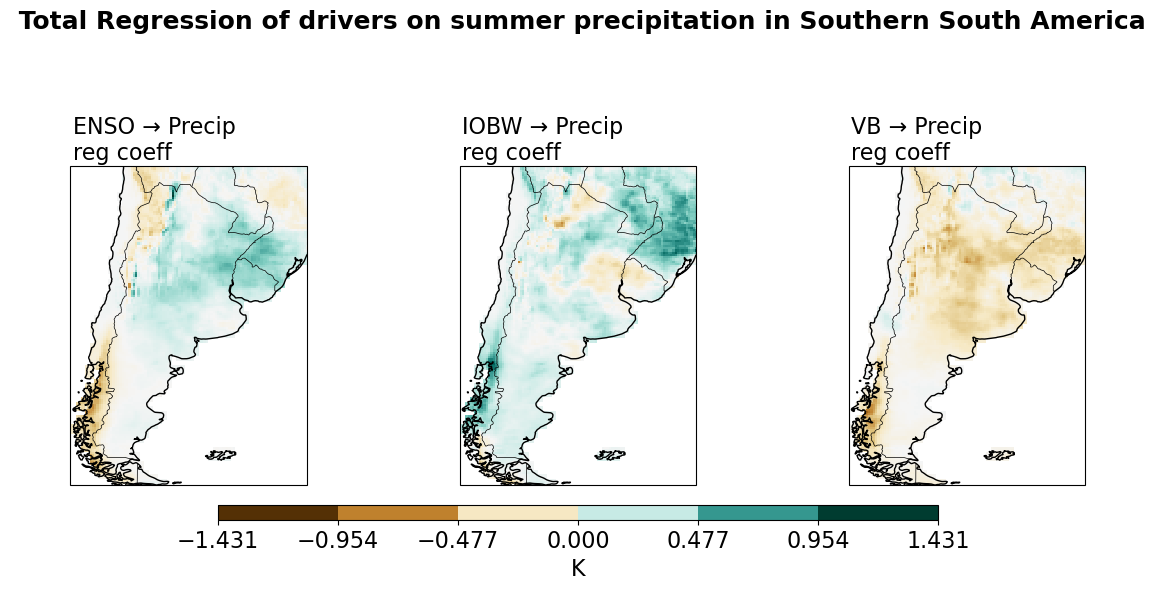

In [40]:
subplots_map(t_reg_LP_DJF_tot, [f"ENSO → T2m \nreg coeff", f"IOBW → T2m \nreg coeff", f"VB → T2m \nreg coeff", \
                      ], heading='Total regression of drivers on summer temperature in Southern South America')
subplots_map(pr_reg_LP_DJF_tot, [f"ENSO → Precip \nreg coeff", f"IOBW → Precip \nreg coeff", f"VB → Precip \nreg coeff"], \
             cmap=plt.cm.BrBG ,heading=' Total Regression of drivers on summer precipitation in Southern South America')